In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("customer_support_tickets.xlsx")


In [4]:
df.head()


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Unnamed: 9,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,NaN,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaT,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,NaN,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaT,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,NaN,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,NaN,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,NaN,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [5]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Unnamed: 9', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [6]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Ticket ID                     8469 non-null   int64         
 1   Customer Name                 8469 non-null   object        
 2   Customer Email                8469 non-null   object        
 3   Customer Age                  8469 non-null   int64         
 4   Customer Gender               8469 non-null   object        
 5   Product Purchased             8469 non-null   object        
 6   Date of Purchase              8469 non-null   datetime64[ns]
 7   Ticket Type                   8469 non-null   object        
 8   Ticket Subject                8469 non-null   object        
 9   Unnamed: 9                    0 non-null      float64       
 10  Ticket Status                 8469 non-null   object        
 11  Resolution                    

In [7]:
df.isnull().sum()


Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Unnamed: 9                      8469
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [8]:
df['Ticket Type'].value_counts()


Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [9]:
df['Ticket Priority'].value_counts()


Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

In [10]:
df['Ticket Status'].value_counts()

Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

In [11]:
df['Product Purchased'].value_counts()


Product Purchased
Canon EOS                         240
GoPro Hero                        228
Nest Thermostat                   225
Philips Hue Lights                221
Amazon Echo                       221
LG Smart TV                       219
Sony Xperia                       217
Roomba Robot Vacuum               216
Apple AirPods                     213
LG OLED                           213
iPhone                            212
Sony 4K HDR TV                    210
Garmin Forerunner                 208
LG Washing Machine                208
Canon DSLR Camera                 206
Nikon D                           204
Nintendo Switch Pro Controller    203
Google Pixel                      203
Fitbit Charge                     202
Sony PlayStation                  202
HP Pavilion                       200
Microsoft Office                  200
Amazon Kindle                     198
Google Nest                       198
Dyson Vacuum Cleaner              198
Bose SoundLink Speaker          

In [12]:
df.drop(columns=[
    'Unnamed: 9',
    'Customer Email',
    'Customer Satisfaction Rating',
    'Resolution'
], inplace=True)


In [13]:
df

,Ticket ID,Customer Name,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution
0,1,Marisa Obrien,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,Pending Customer Response,Critical,Social media,2023-06-01 12:15:36,NaT
1,2,Jessica Rios,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,Pending Customer Response,Critical,Chat,2023-06-01 16:45:38,NaT
2,3,Christopher Robbins,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,Closed,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38
3,4,Christina Dillon,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,Closed,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40
4,5,Alexander Carroll,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,Closed,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,Open,Low,Phone,NaT,NaT
8465,8466,Lori Davis,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,Open,Critical,Email,NaT,NaT
8466,8467,Michelle Kelley,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,Closed,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22
8467,8468,Steven Rodriguez,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,Closed,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24


In [14]:
df['Time to Resolution'] = pd.to_numeric(df['Time to Resolution'], errors='coerce')



In [15]:
df['First Response Time'] = pd.to_numeric(df['First Response Time'], errors='coerce')


In [16]:
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'], errors='coerce')


In [17]:
df

,Ticket ID,Customer Name,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution
0,1,Marisa Obrien,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,Pending Customer Response,Critical,Social media,1685621736000000000,-9223372036854775808
1,2,Jessica Rios,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,Pending Customer Response,Critical,Chat,1685637938000000000,-9223372036854775808
2,3,Christopher Robbins,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,Closed,Low,Social media,1685618078000000000,1685642738000000000
3,4,Christina Dillon,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,Closed,Low,Social media,1685604580000000000,1685584660000000000
4,5,Alexander Carroll,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,Closed,Low,Email,1685578362000000000,1685649222000000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,Open,Low,Phone,-9223372036854775808,-9223372036854775808
8465,8466,Lori Davis,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,Open,Critical,Email,-9223372036854775808,-9223372036854775808
8466,8467,Michelle Kelley,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,Closed,High,Social media,1685612662000000000,1685593882000000000
8467,8468,Steven Rodriguez,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,Closed,Medium,Email,1685644104000000000,1685597544000000000


In [18]:
df.drop_duplicates

<bound method DataFrame.drop_duplicates of       Ticket ID        Customer Name  Customer Age Customer Gender  \
0             1        Marisa Obrien            32           Other   
1             2         Jessica Rios            42          Female   
2             3  Christopher Robbins            48           Other   
3             4     Christina Dillon            27          Female   
4             5    Alexander Carroll            67          Female   
...         ...                  ...           ...             ...   
8464       8465           David Todd            22          Female   
8465       8466           Lori Davis            27          Female   
8466       8467      Michelle Kelley            57          Female   
8467       8468     Steven Rodriguez            54            Male   
8468       8469      Steven Davis MD            53           Other   

           Product Purchased Date of Purchase      Ticket Type  \
0                 GoPro Hero       2021-03-22  Tec

In [19]:
df.fillna("Unknown", inplace=True)


In [20]:
df

,Ticket ID,Customer Name,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution
0,1,Marisa Obrien,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,Pending Customer Response,Critical,Social media,1685621736000000000,-9223372036854775808
1,2,Jessica Rios,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,Pending Customer Response,Critical,Chat,1685637938000000000,-9223372036854775808
2,3,Christopher Robbins,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,Closed,Low,Social media,1685618078000000000,1685642738000000000
3,4,Christina Dillon,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,Closed,Low,Social media,1685604580000000000,1685584660000000000
4,5,Alexander Carroll,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,Closed,Low,Email,1685578362000000000,1685649222000000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,Open,Low,Phone,-9223372036854775808,-9223372036854775808
8465,8466,Lori Davis,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,Open,Critical,Email,-9223372036854775808,-9223372036854775808
8466,8467,Michelle Kelley,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,Closed,High,Social media,1685612662000000000,1685593882000000000
8467,8468,Steven Rodriguez,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,Closed,Medium,Email,1685644104000000000,1685597544000000000


In [21]:
df.isnull().sum()


Ticket ID              0
Customer Name          0
Customer Age           0
Customer Gender        0
Product Purchased      0
Date of Purchase       0
Ticket Type            0
Ticket Subject         0
Ticket Status          0
Ticket Priority        0
Ticket Channel         0
First Response Time    0
Time to Resolution     0
dtype: int64

In [22]:
df

,Ticket ID,Customer Name,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution
0,1,Marisa Obrien,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,Pending Customer Response,Critical,Social media,1685621736000000000,-9223372036854775808
1,2,Jessica Rios,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,Pending Customer Response,Critical,Chat,1685637938000000000,-9223372036854775808
2,3,Christopher Robbins,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,Closed,Low,Social media,1685618078000000000,1685642738000000000
3,4,Christina Dillon,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,Closed,Low,Social media,1685604580000000000,1685584660000000000
4,5,Alexander Carroll,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,Closed,Low,Email,1685578362000000000,1685649222000000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,Open,Low,Phone,-9223372036854775808,-9223372036854775808
8465,8466,Lori Davis,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,Open,Critical,Email,-9223372036854775808,-9223372036854775808
8466,8467,Michelle Kelley,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,Closed,High,Social media,1685612662000000000,1685593882000000000
8467,8468,Steven Rodriguez,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,Closed,Medium,Email,1685644104000000000,1685597544000000000


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Ticket ID            8469 non-null   int64         
 1   Customer Name        8469 non-null   object        
 2   Customer Age         8469 non-null   int64         
 3   Customer Gender      8469 non-null   object        
 4   Product Purchased    8469 non-null   object        
 5   Date of Purchase     8469 non-null   datetime64[ns]
 6   Ticket Type          8469 non-null   object        
 7   Ticket Subject       8469 non-null   object        
 8   Ticket Status        8469 non-null   object        
 9   Ticket Priority      8469 non-null   object        
 10  Ticket Channel       8469 non-null   object        
 11  First Response Time  8469 non-null   int64         
 12  Time to Resolution   8469 non-null   int64         
dtypes: datetime64[ns](1), int64(4), o

In [24]:
df.describe()

,Ticket ID,Customer Age,Date of Purchase,First Response Time,Time to Resolution
count,8469.000000,8469.000000,8469,8.469000e+03,8.469000e+03
mean,4235.000000,44.026804,2020-12-30 01:35:13.071201024,-1.945559e+18,-5.656600e+18
min,1.000000,18.000000,2020-01-01 00:00:00,-9.223372e+18,-9.223372e+18
25%,2118.000000,31.000000,2020-07-02 00:00:00,-9.223372e+18,-9.223372e+18
50%,4235.000000,44.000000,2020-12-31 00:00:00,1.685597e+18,-9.223372e+18
75%,6352.000000,57.000000,2021-07-01 00:00:00,1.685630e+18,1.685596e+18
max,8469.000000,70.000000,2021-12-30 00:00:00,1.685667e+18,1.685667e+18
std,2444.934048,15.296112,NaN,5.141027e+18,5.117725e+18


In [25]:
df['Product Purchased'].value_counts().head(5)


Product Purchased
Canon EOS             240
GoPro Hero            228
Nest Thermostat       225
Philips Hue Lights    221
Amazon Echo           221
Name: count, dtype: int64

In [26]:
df["First Response Time"] = pd.to_datetime(df["First Response Time"], unit="ns", errors="coerce")
df["Time to Resolution"] = pd.to_datetime(df["Time to Resolution"], unit="ns", errors="coerce")


In [27]:
df["Date of Purchase"] = pd.to_datetime(df["Date of Purchase"], errors="coerce")


In [28]:
df["First Response Hours"] = (
    df["First Response Time"] - df["Date of Purchase"]
).dt.total_seconds() / 3600

df["Resolution Hours"] = (
    df["Time to Resolution"] - df["Date of Purchase"]
).dt.total_seconds() / 3600


In [29]:
df["First Response Hours"] = df["First Response Hours"].abs()
df["Resolution Hours"] = df["Resolution Hours"].abs()


In [30]:
df["First Response Hours"] = df["First Response Hours"].round(2)
df["Resolution Hours"] = df["Resolution Hours"].round(2)


In [31]:
df

,Ticket ID,Customer Name,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,First Response Hours,Resolution Hours
0,1,Marisa Obrien,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,Pending Customer Response,Critical,Social media,2023-06-01 12:15:36,NaT,19236.26,NaN
1,2,Jessica Rios,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,Pending Customer Response,Critical,Chat,2023-06-01 16:45:38,NaT,17776.76,NaN
2,3,Christopher Robbins,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,Closed,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,25259.24,25266.09
3,4,Christina Dillon,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,Closed,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,22327.49,22321.96
4,5,Alexander Carroll,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,Closed,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,29112.21,29131.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,Open,Low,Phone,NaT,NaT,NaN,NaN
8465,8466,Lori Davis,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,Open,Critical,Email,NaT,NaT,NaN,NaN
8466,8467,Michelle Kelley,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,Closed,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,15681.74,15676.52
8467,8468,Steven Rodriguez,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,Closed,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,14250.47,14237.54


In [32]:
df["First Response Time"] = pd.to_numeric(df["First Response Time"], errors="coerce")
df["Time to Resolution"] = pd.to_numeric(df["Time to Resolution"], errors="coerce")



In [33]:
df["First Response Hours"] = df["First Response Time"].abs() / 3.6e12
df["Resolution Hours"] = df["Time to Resolution"].abs() / 3.6e12


In [34]:
df[["First Response Hours","Resolution Hours"]].head()


,First Response Hours,Resolution Hours
0,468228.260000,-2.562048e+06
1,468232.760556,-2.562048e+06
2,468227.243889,4.682341e+05
3,468223.494444,4.682180e+05
4,468216.211667,4.682359e+05


In [35]:
df["First Response Minutes"] = df["First Response Hours"] * 60
df["Resolution Days"] = df["Resolution Hours"] / 24


In [36]:
df

,Ticket ID,Customer Name,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,First Response Hours,Resolution Hours,First Response Minutes,Resolution Days
0,1,Marisa Obrien,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,Pending Customer Response,Critical,Social media,1685621736000000000,-9223372036854775808,4.682283e+05,-2.562048e+06,2.809370e+07,-106751.991167
1,2,Jessica Rios,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,Pending Customer Response,Critical,Chat,1685637938000000000,-9223372036854775808,4.682328e+05,-2.562048e+06,2.809397e+07,-106751.991167
2,3,Christopher Robbins,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,Closed,Low,Social media,1685618078000000000,1685642738000000000,4.682272e+05,4.682341e+05,2.809363e+07,19509.753912
3,4,Christina Dillon,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,Closed,Low,Social media,1685604580000000000,1685584660000000000,4.682235e+05,4.682180e+05,2.809341e+07,19509.081713
4,5,Alexander Carroll,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,Closed,Low,Email,1685578362000000000,1685649222000000000,4.682162e+05,4.682359e+05,2.809297e+07,19509.828958
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,Open,Low,Phone,-9223372036854775808,-9223372036854775808,-2.562048e+06,-2.562048e+06,-1.537229e+08,-106751.991167
8465,8466,Lori Davis,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,Open,Critical,Email,-9223372036854775808,-9223372036854775808,-2.562048e+06,-2.562048e+06,-1.537229e+08,-106751.991167
8466,8467,Michelle Kelley,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,Closed,High,Social media,1685612662000000000,1685593882000000000,4.682257e+05,4.682205e+05,2.809354e+07,19509.188449
8467,8468,Steven Rodriguez,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,Closed,Medium,Email,1685644104000000000,1685597544000000000,4.682345e+05,4.682215e+05,2.809407e+07,19509.230833


In [37]:
df.to_csv("final_cleaned_customer_support.csv", index=False)

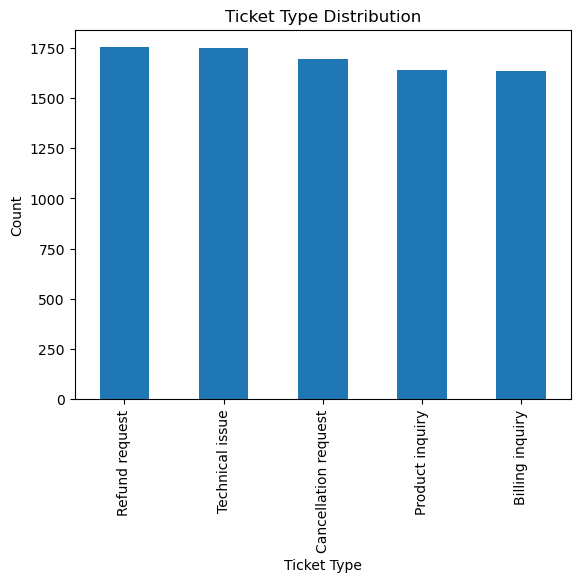

In [38]:
df['Ticket Type'].value_counts().plot(kind='bar')
plt.title("Ticket Type Distribution")
plt.xlabel("Ticket Type")
plt.ylabel("Count")
plt.show()


<Axes: title={'center': 'Avg Resolution Time by Priority'}, xlabel='Ticket Priority'>

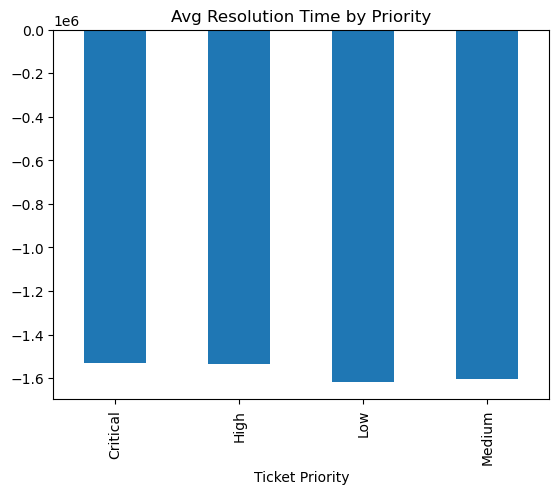

In [39]:
df.groupby("Ticket Priority")["Resolution Hours"].mean().plot(kind="bar", title="Avg Resolution Time by Priority")


<Axes: title={'center': 'Ticket Status Distribution'}, ylabel='count'>

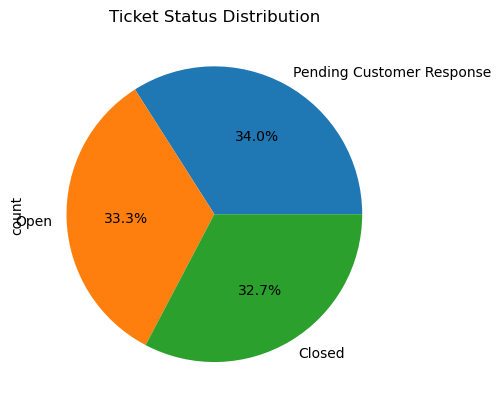

In [40]:
df["Ticket Status"].value_counts().plot(kind="pie", autopct="%1.1f%%", title="Ticket Status Distribution")


<Axes: title={'center': 'Response Time by Channel'}, xlabel='Ticket Channel'>

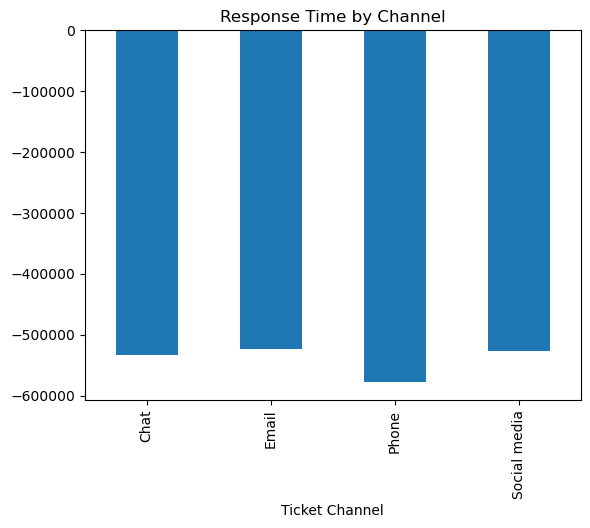

In [41]:
df.groupby("Ticket Channel")["First Response Hours"].mean().plot(kind="bar", title="Response Time by Channel")


In [42]:
priority_map = {
    "Low":1,
    "Medium":2,
    "High":3,
    "Critical":4
}

df["Priority Score"] = df["Ticket Priority"].map(priority_map)


In [43]:
df

,Ticket ID,Customer Name,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,First Response Hours,Resolution Hours,First Response Minutes,Resolution Days,Priority Score
0,1,Marisa Obrien,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,Pending Customer Response,Critical,Social media,1685621736000000000,-9223372036854775808,4.682283e+05,-2.562048e+06,2.809370e+07,-106751.991167,4
1,2,Jessica Rios,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,Pending Customer Response,Critical,Chat,1685637938000000000,-9223372036854775808,4.682328e+05,-2.562048e+06,2.809397e+07,-106751.991167,4
2,3,Christopher Robbins,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,Closed,Low,Social media,1685618078000000000,1685642738000000000,4.682272e+05,4.682341e+05,2.809363e+07,19509.753912,1
3,4,Christina Dillon,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,Closed,Low,Social media,1685604580000000000,1685584660000000000,4.682235e+05,4.682180e+05,2.809341e+07,19509.081713,1
4,5,Alexander Carroll,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,Closed,Low,Email,1685578362000000000,1685649222000000000,4.682162e+05,4.682359e+05,2.809297e+07,19509.828958,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,Open,Low,Phone,-9223372036854775808,-9223372036854775808,-2.562048e+06,-2.562048e+06,-1.537229e+08,-106751.991167,1
8465,8466,Lori Davis,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,Open,Critical,Email,-9223372036854775808,-9223372036854775808,-2.562048e+06,-2.562048e+06,-1.537229e+08,-106751.991167,4
8466,8467,Michelle Kelley,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,Closed,High,Social media,1685612662000000000,1685593882000000000,4.682257e+05,4.682205e+05,2.809354e+07,19509.188449,3
8467,8468,Steven Rodriguez,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,Closed,Medium,Email,1685644104000000000,1685597544000000000,4.682345e+05,4.682215e+05,2.809407e+07,19509.230833,2


In [44]:
df.to_csv("final_cleaned_customer_support.csv", index=False)

In [45]:
df.to_excel("final_cleaned_customer_support.xlsx", index=False)


In [46]:
df[["First Response Time","Time to Resolution"]].dtypes

First Response Time    int64
Time to Resolution     int64
dtype: object

In [47]:
df["First Response Time"] = pd.to_datetime(df["First Response Time"], errors="coerce")
df["Time to Resolution"] = pd.to_datetime(df["Time to Resolution"], errors="coerce")

In [48]:
df["Date of Purchase"] = pd.to_datetime(df["Date of Purchase"])

In [49]:
df["First Response Hours"] = (
    df["First Response Time"] - df["Date of Purchase"]
).dt.total_seconds()/3600

In [50]:
df["Resolution Hours"] = (
    df["Time to Resolution"] - df["Date of Purchase"]
).dt.total_seconds()/3600

In [51]:
df

,Ticket ID,Customer Name,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,First Response Hours,Resolution Hours,First Response Minutes,Resolution Days,Priority Score
0,1,Marisa Obrien,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,Pending Customer Response,Critical,Social media,2023-06-01 12:15:36,NaT,19236.260000,NaN,2.809370e+07,-106751.991167,4
1,2,Jessica Rios,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,Pending Customer Response,Critical,Chat,2023-06-01 16:45:38,NaT,17776.760556,NaN,2.809397e+07,-106751.991167,4
2,3,Christopher Robbins,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,Closed,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,25259.243889,25266.093889,2.809363e+07,19509.753912,1
3,4,Christina Dillon,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,Closed,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,22327.494444,22321.961111,2.809341e+07,19509.081713,1
4,5,Alexander Carroll,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,Closed,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,29112.211667,29131.895000,2.809297e+07,19509.828958,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,Open,Low,Phone,NaT,NaT,NaN,NaN,-1.537229e+08,-106751.991167,1
8465,8466,Lori Davis,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,Open,Critical,Email,NaT,NaT,NaN,NaN,-1.537229e+08,-106751.991167,4
8466,8467,Michelle Kelley,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,Closed,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,15681.739444,15676.522778,2.809354e+07,19509.188449,3
8467,8468,Steven Rodriguez,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,Closed,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,14250.473333,14237.540000,2.809407e+07,19509.230833,2


In [52]:
df["First Response Hours"] = df["First Response Hours"].abs()
df["Resolution Hours"] = df["Resolution Hours"].abs()

In [53]:
df

,Ticket ID,Customer Name,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,First Response Hours,Resolution Hours,First Response Minutes,Resolution Days,Priority Score
0,1,Marisa Obrien,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,Pending Customer Response,Critical,Social media,2023-06-01 12:15:36,NaT,19236.260000,NaN,2.809370e+07,-106751.991167,4
1,2,Jessica Rios,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,Pending Customer Response,Critical,Chat,2023-06-01 16:45:38,NaT,17776.760556,NaN,2.809397e+07,-106751.991167,4
2,3,Christopher Robbins,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,Closed,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,25259.243889,25266.093889,2.809363e+07,19509.753912,1
3,4,Christina Dillon,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,Closed,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,22327.494444,22321.961111,2.809341e+07,19509.081713,1
4,5,Alexander Carroll,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,Closed,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,29112.211667,29131.895000,2.809297e+07,19509.828958,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,Open,Low,Phone,NaT,NaT,NaN,NaN,-1.537229e+08,-106751.991167,1
8465,8466,Lori Davis,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,Open,Critical,Email,NaT,NaT,NaN,NaN,-1.537229e+08,-106751.991167,4
8466,8467,Michelle Kelley,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,Closed,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,15681.739444,15676.522778,2.809354e+07,19509.188449,3
8467,8468,Steven Rodriguez,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,Closed,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,14250.473333,14237.540000,2.809407e+07,19509.230833,2


In [54]:
df[["First Response Hours","Resolution Hours"]].describe()

,First Response Hours,Resolution Hours
count,5650.000000,2769.000000
mean,21232.951597,21234.361898
std,5085.304886,5075.863353
min,12435.146111,12438.464444
25%,16824.263403,16808.266111
50%,21273.225972,21306.388056
75%,25629.607569,25613.881944
max,29944.581944,29947.068889


In [55]:
df.drop(columns=[
    "First Response Minutes",
    "Resolution Days"
], inplace=True)

In [56]:
df

,Ticket ID,Customer Name,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,First Response Hours,Resolution Hours,Priority Score
0,1,Marisa Obrien,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,Pending Customer Response,Critical,Social media,2023-06-01 12:15:36,NaT,19236.260000,NaN,4
1,2,Jessica Rios,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,Pending Customer Response,Critical,Chat,2023-06-01 16:45:38,NaT,17776.760556,NaN,4
2,3,Christopher Robbins,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,Closed,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,25259.243889,25266.093889,1
3,4,Christina Dillon,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,Closed,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,22327.494444,22321.961111,1
4,5,Alexander Carroll,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,Closed,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,29112.211667,29131.895000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,Open,Low,Phone,NaT,NaT,NaN,NaN,1
8465,8466,Lori Davis,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,Open,Critical,Email,NaT,NaT,NaN,NaN,4
8466,8467,Michelle Kelley,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,Closed,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,15681.739444,15676.522778,3
8467,8468,Steven Rodriguez,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,Closed,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,14250.473333,14237.540000,2


In [57]:
df.to_csv("finalized_cleaned_support_data.csv", index=False)